In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score

import joblib

In [137]:
df = pd.read_csv("online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [138]:
# see columns and rows
df.shape

(12330, 18)

In [139]:
# see if there are null values
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [140]:
print(df["Revenue"].value_counts(normalize=True))

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


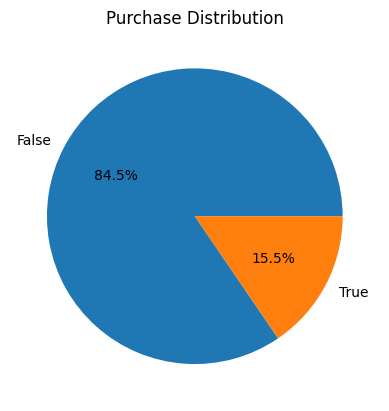

In [141]:
df["Revenue"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Purchase Distribution")
plt.ylabel("")
plt.show()

In [142]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


In [143]:
X = df_encoded.drop(
    "Revenue",
    axis=1
)

y = df_encoded["Revenue"]

print(X.shape)
print(y.shape)

(12330, 26)
(12330,)


In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(9864, 26)
(2466, 26)


In [145]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [146]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=20000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [147]:
y_pred = model.predict(
    X_test_scaled
)

y_pred_prob = model.predict_proba(
    X_test_scaled
)[:,1]

In [148]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy,4))

Accuracy: 0.85


In [149]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

       False       0.95      0.87      0.91      2084
        True       0.51      0.75      0.61       382

    accuracy                           0.85      2466
   macro avg       0.73      0.81      0.76      2466
weighted avg       0.88      0.85      0.86      2466



In [150]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[1810,  274],
       [  96,  286]])

In [151]:
auc_score = roc_auc_score(
    y_test,
    y_pred_prob
)

print("AUC Score:", round(auc_score,4))

AUC Score: 0.8962


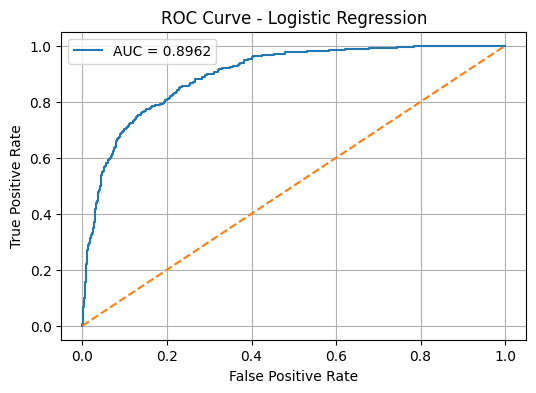

In [152]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.grid(True)

plt.show()

In [153]:
from sklearn.pipeline import make_pipeline

cv_scores = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(
        class_weight='balanced',
        max_iter=20000,
        random_state=42
    )),
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

In [154]:
joblib.dump(
    model,
    "shopping_model.pkl"
)

print("Model Saved")

Model Saved


In [155]:
joblib.dump(
    scaler,
    "shopping_scaler.pkl"
)

print("Scaler Saved")

Scaler Saved
